In [1]:
import os
import pandas as pd

data_dir = "./data"
processed_hourly = os.path.join(data_dir, "morpho_weth_03_processed_hourly.csv")
pool_bigquery    = os.path.join(data_dir, "morpho_weth_03_bigquery.csv")

# 1) Prices from processed-hourly, using the unnamed first column as timestamp index
dfp = pd.read_csv(processed_hourly)

# Use the first column (unnamed) as the timestamp
first_col = dfp.columns[0]
time_col = first_col  # keep exactly the first column
dfp['time'] = pd.to_datetime(dfp[time_col], utc=True, errors='coerce')
dfp = dfp.dropna(subset=['time']).set_index('time').sort_index()

# Extract requested columns exactly as stored
required_price_cols = ['quotePrice', 'token1_usd_price', 'eth_usd_price']
missing = [c for c in required_price_cols if c not in dfp.columns]
assert not missing, f"Processed hourly missing columns: {missing}"

prices = dfp[required_price_cols].astype(float).copy()
prices.index.name = 'time'

print("prices head:")
display(prices.head(5))

# 2) Full swaps from BigQuery CSV (per-swap), robust time parsing
dfs = pd.read_csv(pool_bigquery)

# Try preferred timestamp columns; otherwise auto-detect a datetime-like column
preferred_time_cols = ['block_timestamp', 'time', 'timestamp', 'datetime', 'date']
time_col_swaps = next((c for c in preferred_time_cols if c in dfs.columns), None)
if time_col_swaps is None:
    # Auto-detect: choose first column that parses to datetime for most rows
    for c in dfs.columns:
        cand = pd.to_datetime(dfs[c], utc=True, errors='coerce')
        if cand.notna().mean() > 0.8:
            time_col_swaps = c
            dfs[c] = cand  # keep parsed
            break
    if time_col_swaps is None:
        # Fallback: try first column
        time_col_swaps = dfs.columns[0]

# Ensure datetime index
dfs['time'] = pd.to_datetime(dfs[time_col_swaps], utc=True, errors='coerce')
dfs = dfs.dropna(subset=['time']).set_index('time').sort_index()

swaps_full = dfs.copy()

print("\nswaps_full head:")
display(swaps_full.head(5))

prices head:


,quotePrice,token1_usd_price,eth_usd_price
time,,,
2025-01-01 00:00:00+00:00,0.001024,3.443915,3363.70
2025-01-01 01:00:00+00:00,0.001038,3.473769,3346.54
2025-01-01 02:00:00+00:00,0.001061,3.567391,3362.61
2025-01-01 03:00:00+00:00,0.001043,3.500445,3355.20
2025-01-01 04:00:00+00:00,0.001042,3.482332,3341.14



swaps_full head:


,block_date,block_timestamp,block_number,transaction_hash,log_index,contract_address,sender,recipient,amount0,amount1,...,sqrtPriceX96_float,quotePrice,block_date.1,tick_swap,amount0_adj,amount1_adj,virtual_liquidity,virtual_liquidity_adj,token_in,traded_in
time,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:02:11+00:00,2025-01-01 00:02:11+00:00,2025-01-01 00:02:11+00:00,21525901,0xc2dbf905a0c1c47c3a4bced8c4588bb0ac8f221ab8dd...,240,0xc8219b876753a85025156b22176c2edea17aac53,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,6.615809e+20,-6.866976e+17,...,2.555252e+27,0.001040,2025-01-01 00:02:11+00:00,-68688,661.580910,-0.686698,2.437643e+22,24376.425759,token1,0.686698
2025-01-01 00:04:23+00:00,2025-01-01 00:04:23+00:00,2025-01-01 00:04:23+00:00,21525912,0xb7de8cf71527b137c7456e5c67d27a6efddfb7077ef0...,56,0xc8219b876753a85025156b22176c2edea17aac53,0x51c72848c68a965f66fa7a88855f9f7784502a7f,0x51c72848c68a965f66fa7a88855f9f7784502a7f,7.249430e+20,-7.510903e+17,...,2.552811e+27,0.001038,2025-01-01 00:04:23+00:00,-68707,724.943003,-0.751090,2.437643e+22,24376.425759,token1,0.751090
2025-01-01 00:06:23+00:00,2025-01-01 00:06:23+00:00,2025-01-01 00:06:23+00:00,21525922,0xc79ec3dc4a4182090d4fe2f4da17d022bfa8fda2ca93...,51,0xc8219b876753a85025156b22176c2edea17aac53,0x51c72848c68a965f66fa7a88855f9f7784502a7f,0x51c72848c68a965f66fa7a88855f9f7784502a7f,8.179087e+20,-8.456879e+17,...,2.550062e+27,0.001036,2025-01-01 00:06:23+00:00,-68728,817.908687,-0.845688,2.437643e+22,24376.425759,token1,0.845688
2025-01-01 00:07:35+00:00,2025-01-01 00:07:35+00:00,2025-01-01 00:07:35+00:00,21525928,0x64a12451f6c5c40c76e5aac1debbb261b9c586c2e37f...,64,0xc8219b876753a85025156b22176c2edea17aac53,0x51c72848c68a965f66fa7a88855f9f7784502a7f,0x51c72848c68a965f66fa7a88855f9f7784502a7f,7.280478e+20,-7.512445e+17,...,2.547620e+27,0.001034,2025-01-01 00:07:35+00:00,-68747,728.047791,-0.751244,2.437643e+22,24376.425759,token1,0.751244
2025-01-01 00:07:59+00:00,2025-01-01 00:07:59+00:00,2025-01-01 00:07:59+00:00,21525930,0x2f7e3a081efca1f7bc6cb471f77071beab13ff4e9717...,526,0xc8219b876753a85025156b22176c2edea17aac53,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,6.628288e+20,-6.826975e+17,...,2.545401e+27,0.001032,2025-01-01 00:07:59+00:00,-68765,662.828788,-0.682697,2.437643e+22,24376.425759,token1,0.682697


In [2]:
# 1) price_data: take the 'quote' column from prices
price_data = prices['quotePrice']

# 2) swap_data: use the full swaps as-is
swap_data = swaps_full

# 3) token_0_usd_data: take 'token1_usd_price' from prices (renamed to 'quotePrice' for compatibility)
token_0_usd_data = prices[['token1_usd_price']].rename(columns={'token1_usd_price': 'token0_usd_price'})
# FOR INVERSE POOL ITS THE OPPOSITE
# Show heads
print("price_data head:")
print(price_data.head())

print("\nswap_data head:")
print(swap_data.head())

print("\ntoken_0_usd_data head:")
print(token_0_usd_data.head())

price_data head:
time
2025-01-01 00:00:00+00:00    0.001024
2025-01-01 01:00:00+00:00    0.001038
2025-01-01 02:00:00+00:00    0.001061
2025-01-01 03:00:00+00:00    0.001043
2025-01-01 04:00:00+00:00    0.001042
Name: quotePrice, dtype: float64

swap_data head:
                                          block_date  \
time                                                   
2025-01-01 00:02:11+00:00  2025-01-01 00:02:11+00:00   
2025-01-01 00:04:23+00:00  2025-01-01 00:04:23+00:00   
2025-01-01 00:06:23+00:00  2025-01-01 00:06:23+00:00   
2025-01-01 00:07:35+00:00  2025-01-01 00:07:35+00:00   
2025-01-01 00:07:59+00:00  2025-01-01 00:07:59+00:00   

                                     block_timestamp  block_number  \
time                                                                 
2025-01-01 00:02:11+00:00  2025-01-01 00:02:11+00:00      21525901   
2025-01-01 00:04:23+00:00  2025-01-01 00:04:23+00:00      21525912   
2025-01-01 00:06:23+00:00  2025-01-01 00:06:23+00:00      2152592

In [10]:
from OptimalRangeStrategy_FromSimple import OptimalRangeStrategy
from ActiveStrategyFramework import simulate_strategy, generate_simulation_series, analyze_strategy, plot_strategy, plot_position_value, plot_position_return_decomposition
import pandas as pd

# Window
start_ts = pd.Timestamp('2025-02-27 00:00:00', tz='UTC')
end_ts   = pd.Timestamp('2025-08-01 00:00:00', tz='UTC')

# Slice inputs (use exactly these columns from your prices df)
price_week = prices['quotePrice'].loc[start_ts:end_ts]
token0_usd_week = prices[['token1_usd_price']].rename(columns={'token1_usd_price':'quotePrice'}).loc[start_ts:end_ts]
swaps_week = swaps_full.loc[start_ts:end_ts]

# Volatility/correlation (from prepared file)
vol_file = "./data/pool_volatility_correlation/morpho_weth_volatility_correlation.csv"
vol_df = pd.read_csv(vol_file)
vol_df['datetime'] = pd.to_datetime(vol_df['datetime'], utc=True, errors='coerce')
vol_df = vol_df.dropna(subset=['datetime']).set_index('datetime').sort_index()
vol_week = vol_df[['cross_price_volatility','correlation']].loc[start_ts:end_ts]

print("vol_week head:")
print(vol_week.head())

# Initial 50/50 USD at t0
initial_usd = 10_000.0
t0 = price_week.index[0]
p_t0 = float(price_week.iloc[0])
p0usd_t0 = float(token0_usd_week.iloc[0, 0])  # MORPHO/USD
token1_usd_t0 = p0usd_t0 / p_t0
amt0 = (initial_usd / 2.0) / p0usd_t0
amt1 = (initial_usd / 2.0) / token1_usd_t0

# Strategy (optimal range; rebalance every 3 days)
strategy = OptimalRangeStrategy(
    volatility_data=vol_week,
    rebalance_days=2,
    alpha_range=(1.02, 2.0),
    alpha_steps=50,
    days_in_year=365
)

# Simulate
sims = simulate_strategy(
    price_data=price_week,
    swap_data=swaps_week,
    strategy_in=strategy,
    liquidity_in_0=float(amt0),
    liquidity_in_1=float(amt1),
    fee_tier=0.003,
    decimals_0=18,
    decimals_1=18,
    token_0_usd_data=token0_usd_week
)

results_opt = generate_simulation_series(sims, strategy_in=strategy, token_0_usd_data=token0_usd_week)
print(results_opt[['time','price','value_position_usd','cum_fees_usd']].head())
performance = analyze_strategy(results_opt, frequency='H')

vol_week head:
                           cross_price_volatility  correlation
datetime                                                      
2025-02-27 00:00:00+00:00                0.849681     0.765784
2025-02-27 01:00:00+00:00                0.840371     0.766815
2025-02-27 02:00:00+00:00                0.835834     0.763939
2025-02-27 03:00:00+00:00                0.837023     0.760110
2025-02-27 04:00:00+00:00                0.831696     0.763227


/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strategy_results.append(StrategyObservation(price_data.index[i], price_data[i], strategy_in,
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:115: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strategy_results.append(StrategyObservation(price_data.index[i], price_data[i], strategy_in,


                       time     price  value_position_usd  cum_fees_usd
0 2025-02-27 00:00:00+00:00  0.000871        10000.000000      0.000000
1 2025-02-27 01:00:00+00:00  0.000873        10038.895164      0.433441
2 2025-02-27 02:00:00+00:00  0.000878        10027.702007      1.066431
3 2025-02-27 03:00:00+00:00  0.000889        10073.560999      1.627425
4 2025-02-27 04:00:00+00:00  0.000885         9965.984925      2.642191


/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


In [4]:
results_opt.to_csv('results_opt.csv')

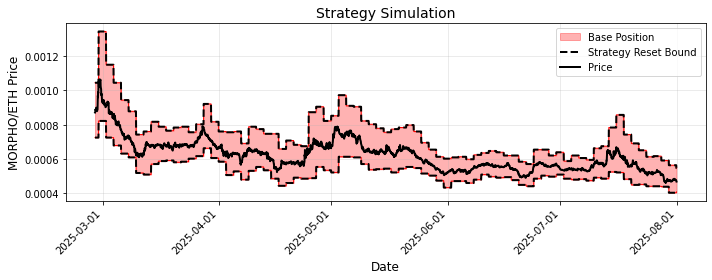

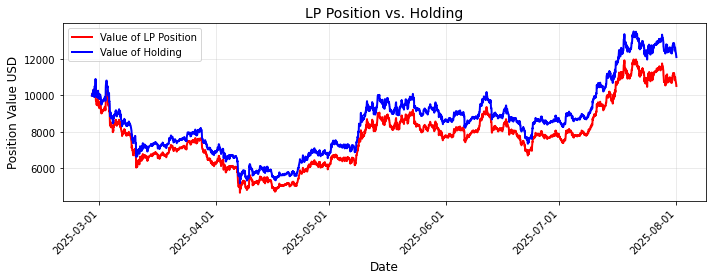

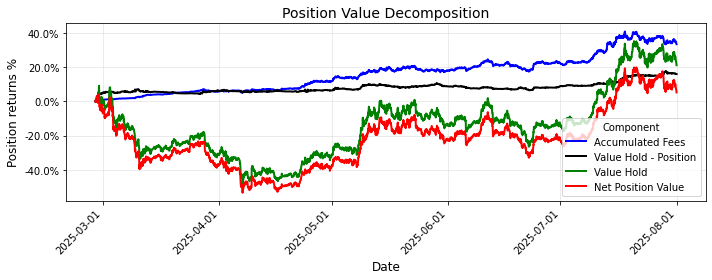

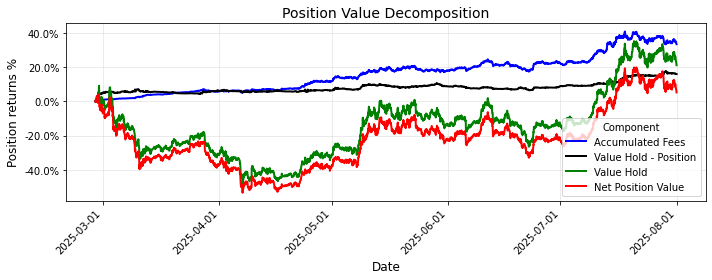

In [11]:
import pandas as pd
from ActiveStrategyFramework import (
    analyze_strategy,
    plot_strategy,
    plot_position_value,
    plot_position_return_decomposition
)


plot_strategy(results_opt, "MORPHO/ETH Price")
plot_position_value(results_opt)
plot_position_return_decomposition(results_opt)

In [12]:
# Rebalance events with optimal alpha
cols = ['time','reset_reason','optimal_alpha','price_at_reset',
        'reset_range_lower','reset_range_upper','volatility_at_reset','correlation_at_reset']

rebals = results_opt.loc[results_opt['reset_point'] == True, [c for c in cols if c in results_opt.columns]].copy()
rebals = rebals.sort_values('time')

print("Rebalances:", len(rebals))
display(rebals)

Rebalances: 78


,time,reset_reason,optimal_alpha,price_at_reset,reset_range_lower,reset_range_upper,volatility_at_reset,correlation_at_reset
23,2025-02-27 23:00:00+00:00,out_of_range,1.28,0.001053,0.000822,0.001345,1.277590,0.652977
71,2025-03-01 23:00:00+00:00,scheduled_rebalance,1.26,0.000913,0.000725,0.001150,1.138825,0.620854
119,2025-03-03 23:00:00+00:00,scheduled_rebalance,1.24,0.000841,0.000678,0.001045,0.992778,0.799445
167,2025-03-05 23:00:00+00:00,scheduled_rebalance,1.22,0.000772,0.000631,0.000944,0.870243,0.728285
215,2025-03-07 23:00:00+00:00,scheduled_rebalance,1.20,0.000730,0.000609,0.000878,0.806792,0.715530
...,...,...,...,...,...,...,...,...
3527,2025-07-23 23:00:00+00:00,scheduled_rebalance,1.18,0.000520,0.000440,0.000613,0.694665,0.777927
3575,2025-07-25 23:00:00+00:00,scheduled_rebalance,1.18,0.000521,0.000440,0.000616,0.700010,0.873695
3623,2025-07-27 23:00:00+00:00,scheduled_rebalance,1.16,0.000509,0.000438,0.000591,0.613807,0.810680
3671,2025-07-29 23:00:00+00:00,scheduled_rebalance,1.18,0.000476,0.000403,0.000563,0.752826,0.804469


In [13]:
# Import the updated hedging function
from hedging import apply_delta_hedging

# Ensure required columns are present and properly named
results_opt['time_pd'] = pd.to_datetime(results_opt['time'], utc=True)
results_opt = results_opt.sort_values('time_pd')

# Apply hedging to the results
res_hedged = apply_delta_hedging(
    strategy_df=results_opt,
    token0_symbol_slug='morpho',
    token1_symbol_slug='eth',
    price_source='usd',
    token0_usd_col='price_0_usd',       # existing in results_opt
    token1_usd_col=None,                 # derive from token0_usd / quote price
    quote_price_col='price',             # results_opt['price'] is token1 per token0
    fee_rate=0.0002,
    time_col='time_pd',
    token0_total_col='token_0_total',
    token1_total_col='token_1_total',
    reset_flag_col='reset_point',
    value_usd_col='value_position_usd'
)

# Save hedged results
res_hedged.to_csv('results_opt_hedged.csv')


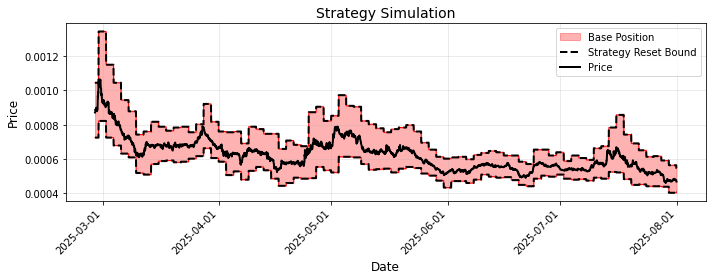

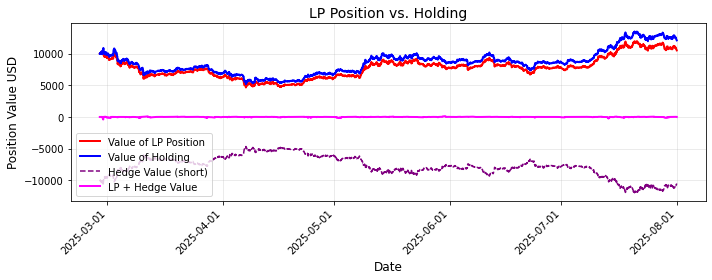

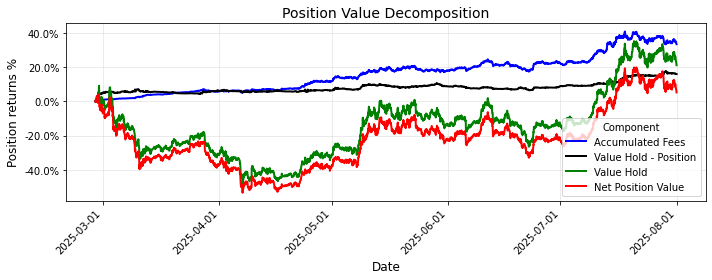

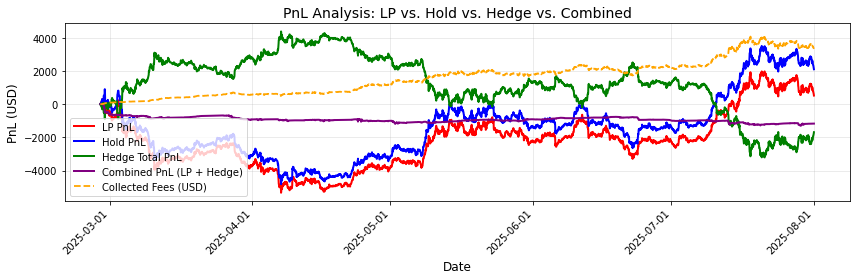

{'days_strategy': 155, 'gross_fee_apr': 0.7849090776986095, 'gross_fee_return': 0.33331755354324516, 'net_apr': 0.12228783569413303, 'net_return': 0.05193045077422087, 'rebalances': 78, 'compounds': 0, 'max_drawdown': 0.6108130176062272, 'volatility': 0.8582478185053479, 'sharpe_ratio': 0.14248546055974742, 'impermanent_loss': -0.13095152316539202, 'mean_base_position': 0.9950238051873821, 'median_base_position': 0.9961983189267462, 'mean_base_width': 0.34042623257410753, 'median_base_width': 0.33145422591640866, 'final_value': 10519.304507742208, 'net_apr_hedged': -0.2758700806736635, 'net_return_hedged': -0.11715030823128175, 'volatility_hedged': 0.09750392461436853, 'sharpe_ratio_hedged': -2.829322837667708, 'max_drawdown_hedged': 0.1310822394079102, 'final_value_hedged': 8828.496917687182}


/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


In [14]:
from ActiveStrategyFramework import plot_strategy, plot_position_value, plot_position_return_decomposition, plot_pnl_analysis, analyze_strategy

# Existing plots
_ = plot_strategy(res_hedged, "Price")
_ = plot_position_value(res_hedged)                 # LP vs HOLD value
_ = plot_position_return_decomposition(res_hedged)  # Decomposition (as in your first image)

# New PnL analysis plot (as in your second image)
_ = plot_pnl_analysis(res_hedged)

# Strategy stats
stats = analyze_strategy(res_hedged, frequency='H')
print(stats)

In [15]:
from ActiveStrategyFramework import analyze_strategy
stats = analyze_strategy(res_hedged, frequency='H')
print(stats)

{'days_strategy': 155, 'gross_fee_apr': 0.7849090776986095, 'gross_fee_return': 0.33331755354324516, 'net_apr': 0.12228783569413303, 'net_return': 0.05193045077422087, 'rebalances': 78, 'compounds': 0, 'max_drawdown': 0.6108130176062272, 'volatility': 0.8582478185053479, 'sharpe_ratio': 0.14248546055974742, 'impermanent_loss': -0.13095152316539202, 'mean_base_position': 0.9950238051873821, 'median_base_position': 0.9961983189267462, 'mean_base_width': 0.34042623257410753, 'median_base_width': 0.33145422591640866, 'final_value': 10519.304507742208, 'net_apr_hedged': -0.2758700806736635, 'net_return_hedged': -0.11715030823128175, 'volatility_hedged': 0.09750392461436853, 'sharpe_ratio_hedged': -2.829322837667708, 'max_drawdown_hedged': 0.1310822394079102, 'final_value_hedged': 8828.496917687182}


/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


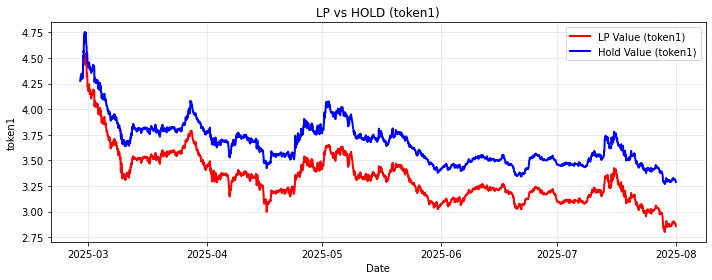

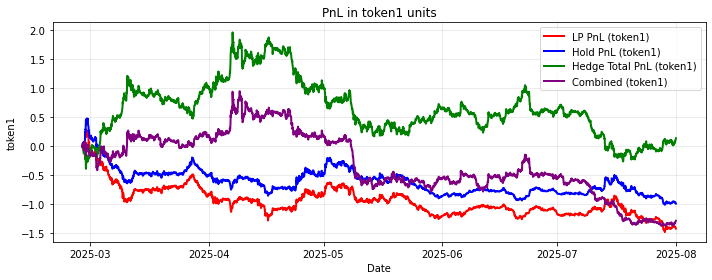

In [16]:
# Hedge only token0 and report in token1 units
from hedging import apply_delta_hedging
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ensure time column
results_opt['time_pd'] = pd.to_datetime(results_opt['time'], utc=True, errors='coerce')

res_t1 = apply_delta_hedging(
    strategy_df=results_opt,
    token0_symbol_slug='morpho',     # adjust symbols if needed
    token1_symbol_slug='eth',
    price_source='usd',              # use pool USD prices already in results_opt
    token0_usd_col='price_0_usd',
    token1_usd_col=None,             # derive token1 USD = token0_usd / price
    quote_price_col='price',
    hedge_only='token0',             # only short token0
    reporting_unit='token1'          # adds token1-valued columns
).sort_values('time_pd')

# PnL in token1 units
init_t1 = float(res_t1['value_position_token1'].iloc[0])
lp_pnl_t1    = (res_t1['value_position_token1'] - init_t1)
hold_pnl_t1  = (res_t1['value_hold_token1']     - init_t1)
hedge_pnl_t1 = res_t1['hedge_realized_pnl_total_token1'].fillna(0.0) + res_t1['hedge_unrealized_pnl_total_token1'].fillna(0.0)
combined_t1  = (lp_pnl_t1 + hedge_pnl_t1)

# Plot values (token1)
x = res_t1['time_pd'].to_numpy()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, res_t1['value_position_token1'].to_numpy().ravel(), color='red',  lw=2, label='LP Value (token1)')
ax.plot(x, res_t1['value_hold_token1'].to_numpy().ravel(),     color='blue', lw=2, label='Hold Value (token1)')
ax.set_title('LP vs HOLD (token1)'); ax.set_xlabel('Date'); ax.set_ylabel('token1')
ax.grid(True, alpha=0.3); ax.legend(loc='best'); plt.tight_layout(); plt.show()

# Plot PnL (token1)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, lp_pnl_t1.to_numpy().ravel(),        color='red',    lw=2, label='LP PnL (token1)')
ax.plot(x, hold_pnl_t1.to_numpy().ravel(),      color='blue',   lw=2, label='Hold PnL (token1)')
ax.plot(x, hedge_pnl_t1.to_numpy().ravel(),     color='green',  lw=2, label='Hedge Total PnL (token1)')
ax.plot(x, combined_t1.to_numpy().ravel(),      color='purple', lw=2, label='Combined (token1)')
ax.set_title('PnL in token1 units'); ax.set_xlabel('Date'); ax.set_ylabel('token1')
ax.grid(True, alpha=0.3); ax.legend(loc='best'); plt.tight_layout(); plt.show()

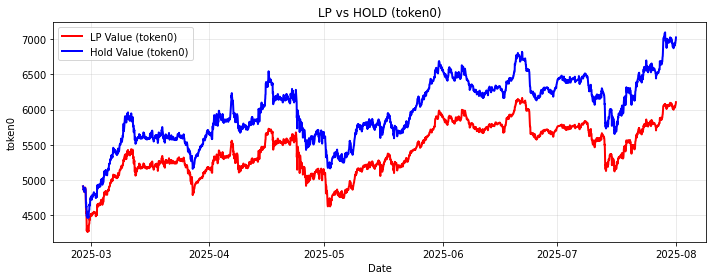

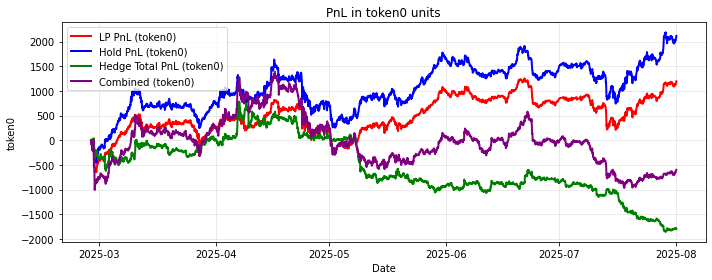

In [17]:
# Hedge only token1 and report in token0 units
from hedging import apply_delta_hedging
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

results_opt['time_pd'] = pd.to_datetime(results_opt['time'], utc=True, errors='coerce')

res_t0_usd = apply_delta_hedging(
    strategy_df=results_opt,
    token0_symbol_slug='morpho',
    token1_symbol_slug='eth',
    price_source='usd',
    token0_usd_col='price_0_usd',
    token1_usd_col=None,
    quote_price_col='price',
    hedge_only='token1',            # only short token1
    reporting_unit='usd'            # we will convert to token0 below
).sort_values('time_pd')

# Convert USD-valued columns to token0 units using token0 USD price
conv0 = res_t0_usd['token0_usd_price'].astype(float).replace(0.0, np.nan)

res_t0 = res_t0_usd.copy()
res_t0['value_position_token0']        = res_t0['value_position_usd']        / conv0
res_t0['value_hold_token0']            = res_t0['value_hold_usd']            / conv0
res_t0['hedge_value_token0']           = res_t0['hedge_value_usd']           / conv0
res_t0['value_position_hedged_token0'] = res_t0['value_position_hedged_usd'] / conv0
res_t0['hedge_realized_pnl_total_token0']   = res_t0['hedge_realized_pnl_usd']   / conv0
res_t0['hedge_unrealized_pnl_total_token0'] = res_t0['hedge_unrealized_pnl_usd'] / conv0

# PnL in token0 units
init_t0 = float(res_t0['value_position_token0'].iloc[0])
lp_pnl_t0    = (res_t0['value_position_token0'] - init_t0)
hold_pnl_t0  = (res_t0['value_hold_token0']     - init_t0)
hedge_pnl_t0 = res_t0['hedge_realized_pnl_total_token0'].fillna(0.0) + res_t0['hedge_unrealized_pnl_total_token0'].fillna(0.0)
combined_t0  = (lp_pnl_t0 + hedge_pnl_t0)

# Plot values (token0)
x = res_t0['time_pd'].to_numpy()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, res_t0['value_position_token0'].to_numpy().ravel(), color='red',  lw=2, label='LP Value (token0)')
ax.plot(x, res_t0['value_hold_token0'].to_numpy().ravel(),     color='blue', lw=2, label='Hold Value (token0)')
ax.set_title('LP vs HOLD (token0)'); ax.set_xlabel('Date'); ax.set_ylabel('token0')
ax.grid(True, alpha=0.3); ax.legend(loc='best'); plt.tight_layout(); plt.show()

# Plot PnL (token0)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, lp_pnl_t0.to_numpy().ravel(),        color='red',    lw=2, label='LP PnL (token0)')
ax.plot(x, hold_pnl_t0.to_numpy().ravel(),      color='blue',   lw=2, label='Hold PnL (token0)')
ax.plot(x, hedge_pnl_t0.to_numpy().ravel(),     color='green',  lw=2, label='Hedge Total PnL (token0)')
ax.plot(x, combined_t0.to_numpy().ravel(),      color='purple', lw=2, label='Combined (token0)')
ax.set_title('PnL in token0 units'); ax.set_xlabel('Date'); ax.set_ylabel('token0')
ax.grid(True, alpha=0.3); ax.legend(loc='best'); plt.tight_layout(); plt.show()